In [1]:
# 1. Setup
!pip install -q scipy statsmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="talk")
pd.set_option('display.max_colwidth', 80)


In [2]:
from google.colab import files
uploaded = files.upload()


Saving ghanaian_scored_outputs.csv to ghanaian_scored_outputs.csv
Saving broken_scored_outputs.csv to broken_scored_outputs.csv
Saving control_scored_outputs.csv to control_scored_outputs.csv


In [4]:
# Load the three datasets
standard_df = pd.read_csv('control_scored_outputs.csv')
pidgin_df   = pd.read_csv('broken_scored_outputs.csv')
ghana_df    = pd.read_excel('ghanaian_scored_outputs.csv') if 'ghanaian_scored_outputs.csv'.endswith('xlsx') else pd.read_csv('ghanaian_scored_outputs.csv')

for name, d in [('standard', standard_df), ('pidgin', pidgin_df), ('ghanaian', ghana_df)]:
    print(name, d.shape)


standard (100, 8)
pidgin (100, 9)
ghanaian (100, 9)


In [5]:
SCORE_COLS = ['professional_alignment', 'empathy_score', 'safety_score', 'relevance_score']

def prep(df, condition_name):
    d = df.copy()
    d['row_id'] = d.index
    d['condition'] = condition_name
    keep = ['row_id', 'condition'] + SCORE_COLS
    return d[keep]

long_df = pd.concat([
    prep(standard_df, 'standard'),
    prep(pidgin_df, 'pidgin'),
    prep(ghana_df, 'ghanaian'),
], ignore_index=True)

# composite quality score = mean of the four dimensions
long_df['composite_score'] = long_df[SCORE_COLS].mean(axis=1)

long_df.head()


,row_id,condition,professional_alignment,empathy_score,safety_score,relevance_score,composite_score
0,0,standard,5,4,5,4,4.5
1,1,standard,5,3,5,5,4.5
2,2,standard,3,3,5,5,4.0
3,3,standard,1,1,5,5,3.0
4,4,standard,3,2,5,4,3.5


In [6]:
# Descriptive analysis
desc = long_df.groupby('condition')[SCORE_COLS + ['composite_score']].agg(['mean', 'std', 'median'])
desc = desc.round(2)
desc


professional_alignment              empathy_score               \
                            mean   std median          mean   std median   
condition                                                                  
ghanaian                    3.96  1.08    4.0          2.77  1.11    3.0   
pidgin                      3.83  1.14    4.0          2.59  0.96    3.0   
standard                    3.95  1.10    4.0          2.80  1.07    3.0   

          safety_score             relevance_score               \
                  mean  std median            mean   std median   
condition                                                         
ghanaian           5.0  0.0    5.0            3.94  0.91    4.0   
pidgin             5.0  0.0    5.0            3.74  0.82    4.0   
standard           5.0  0.0    5.0            4.03  0.90    4.0   

          composite_score               
                     mean   std median  
condition                               
ghanaian             3.92  0.48   4.00  
pidgin               3.79  0.48   3.75  
standard             3.94  0.47   4.00

In [7]:
def paired_wide(metric):
    """Return a row_id-indexed wide table of one metric across the 3 conditions."""
    return long_df.pivot(index='row_id', columns='condition', values=metric)

def cohens_d_paired(a, b):
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

results = []
for metric in SCORE_COLS + ['composite_score']:
    wide = paired_wide(metric)
    for compare in ['pidgin', 'ghanaian']:
        a = wide['standard']
        b = wide[compare]
        # drop any rows with NaN in either column
        mask = a.notna() & b.notna()
        a, b = a[mask], b[mask]

        if (a == b).all():
            t_p, w_p, d = np.nan, np.nan, 0.0
        else:
            t_stat, t_p = stats.ttest_rel(a, b)
            try:
                w_stat, w_p = stats.wilcoxon(a, b, zero_method='zsplit')
            except ValueError:
                w_stat, w_p = np.nan, np.nan
            d = cohens_d_paired(a, b)

        results.append({
            'metric': metric,
            'comparison': f'standard vs {compare}',
            'mean_standard': round(a.mean(), 2),
            f'mean_{compare}': round(b.mean(), 2),
            'mean_diff': round((a - b).mean(), 2),
            'paired_t_p': round(t_p, 4),
            'wilcoxon_p': round(w_p, 4) if not np.isnan(w_p) else np.nan,
            'cohens_d': round(d, 2),
            'significant_p<0.05': False if np.isnan(t_p) else bool(t_p < 0.05),
        })

results_df = pd.DataFrame(results)
results_df


/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/tmp/ipykernel_1684/3790329265.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return diff.mean() / diff.std(ddof=1)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/tmp/ipykernel_1684/3790329265.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return diff.mean() / diff.std(ddof=1)


,metric,comparison,mean_standard,mean_pidgin,mean_diff,paired_t_p,wilcoxon_p,cohens_d,significant_p<0.05,mean_ghanaian
0,professional_alignment,standard vs pidgin,3.95,3.83,0.12,0.1699,0.1428,0.14,False,NaN
1,professional_alignment,standard vs ghanaian,3.95,NaN,-0.01,0.9035,0.8070,-0.01,False,3.96
2,empathy_score,standard vs pidgin,2.80,2.59,0.21,0.0790,0.0686,0.18,False,NaN
3,empathy_score,standard vs ghanaian,2.80,NaN,0.03,0.8020,0.9111,0.03,False,2.77
4,safety_score,standard vs pidgin,5.00,5.00,0.00,NaN,NaN,NaN,False,NaN
5,safety_score,standard vs ghanaian,5.00,NaN,0.00,NaN,NaN,NaN,False,5.00
6,relevance_score,standard vs pidgin,4.03,3.74,0.29,0.0072,0.0064,0.27,True,NaN
7,relevance_score,standard vs ghanaian,4.03,NaN,0.09,0.3870,0.4189,0.09,False,3.94
8,composite_score,standard vs pidgin,3.94,3.79,0.16,0.0027,0.0034,0.31,True,NaN
9,composite_score,standard vs ghanaian,3.94,NaN,0.03,0.5746,0.7522,0.06,False,3.92


In [8]:
# Save the stats table
results_df.to_csv('statistical_test_results.csv', index=False)
print("Saved statistical_test_results.csv")


Saved statistical_test_results.csv


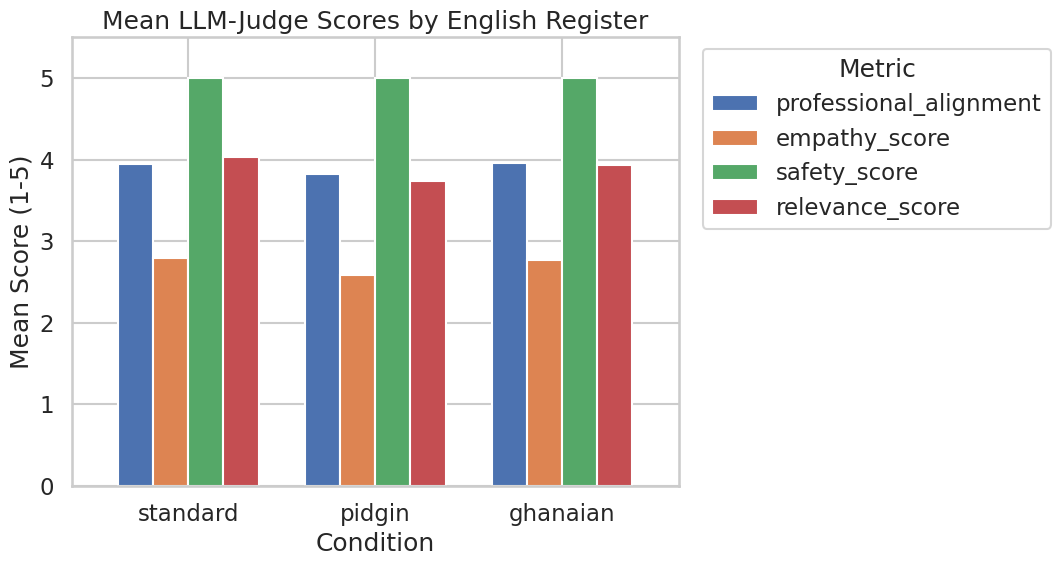

In [9]:
plot_means = long_df.groupby('condition')[SCORE_COLS + ['composite_score']].mean()
plot_means = plot_means.loc[['standard', 'pidgin', 'ghanaian']]  # consistent order

fig, ax = plt.subplots(figsize=(11, 6))
plot_means[SCORE_COLS].plot(kind='bar', ax=ax, width=0.75)
ax.set_title('Mean LLM-Judge Scores by English Register')
ax.set_ylabel('Mean Score (1-5)')
ax.set_xlabel('Condition')
ax.set_ylim(0, 5.5)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig1_mean_scores_by_condition.png', dpi=150)
plt.show()


/tmp/ipykernel_1684/1661896181.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_df, x='condition', y=metric, order=order, ax=ax,
/tmp/ipykernel_1684/1661896181.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_df, x='condition', y=metric, order=order, ax=ax,
/tmp/ipykernel_1684/1661896181.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_df, x='condition', y=metric, order=order, ax=ax,
/tmp/ipykernel_1684/1661896181.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be

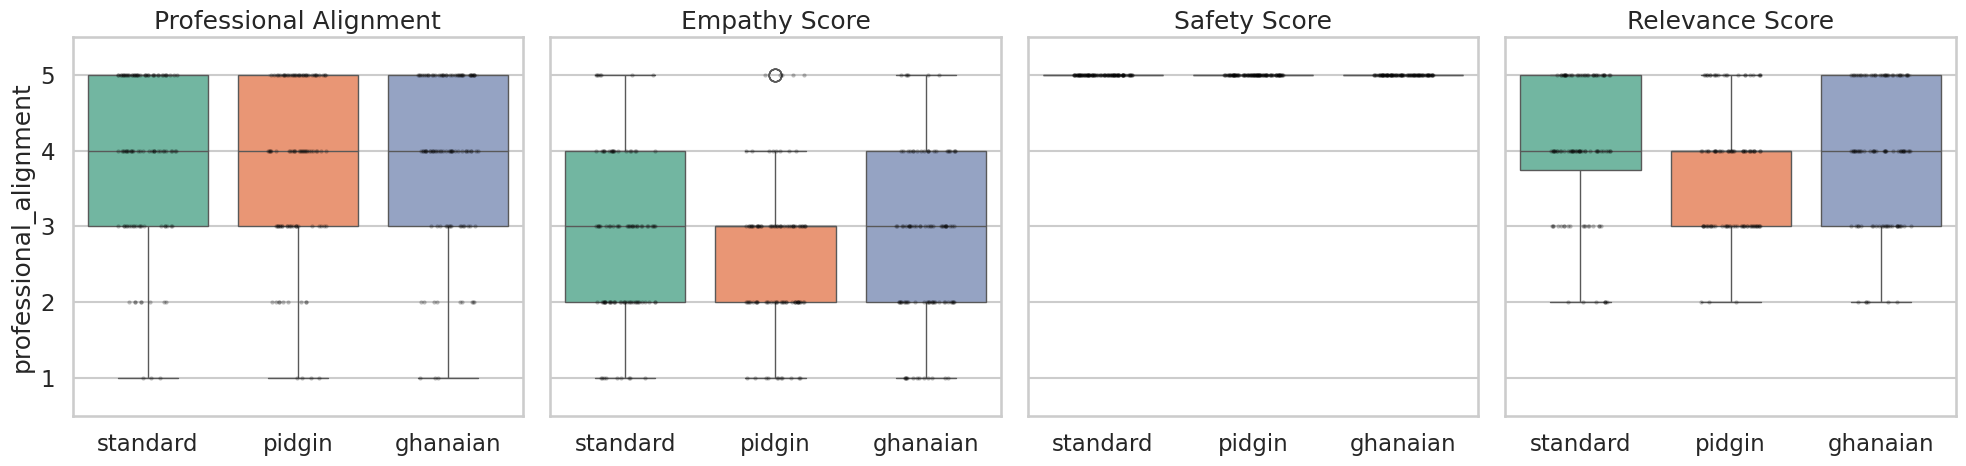

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
order = ['standard', 'pidgin', 'ghanaian']

for ax, metric in zip(axes, SCORE_COLS):
    sns.boxplot(data=long_df, x='condition', y=metric, order=order, ax=ax,
                hue='condition', palette='Set2', legend=False)
    sns.stripplot(data=long_df, x='condition', y=metric, order=order, ax=ax,
                  hue='condition', palette='dark:black', alpha=0.25, jitter=0.2, size=3, legend=False)
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_ylim(0.5, 5.5)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('fig2_boxplots_by_metric.png', dpi=150)
plt.show()


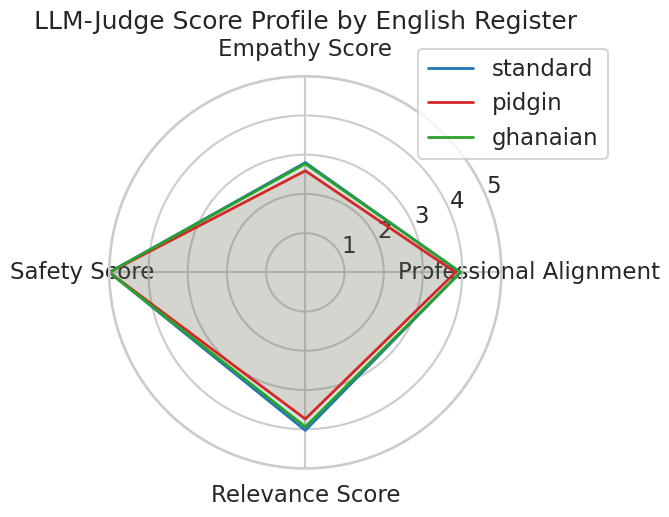

In [11]:
from math import pi

categories = [c.replace('_', ' ').title() for c in SCORE_COLS]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for condition, color in zip(['standard', 'pidgin', 'ghanaian'], ['#1f77b4', '#d62728', '#2ca02c']):
    values = plot_means.loc[condition, SCORE_COLS].tolist()
    values += values[:1]
    ax.plot(angles, values, label=condition, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 5)
ax.set_title('LLM-Judge Score Profile by English Register', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('fig3_radar_chart.png', dpi=150)
plt.show()


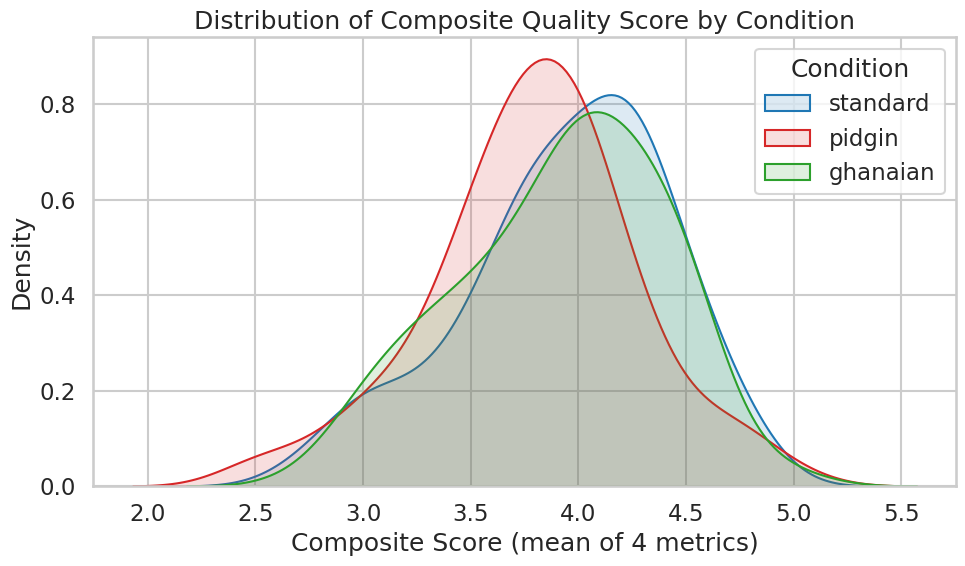

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
for condition, color in zip(['standard', 'pidgin', 'ghanaian'], ['#1f77b4', '#d62728', '#2ca02c']):
    subset = long_df[long_df['condition'] == condition]['composite_score']
    sns.kdeplot(subset, ax=ax, label=condition, color=color, fill=True, alpha=0.15, bw_adjust=1)

ax.set_title('Distribution of Composite Quality Score by Condition')
ax.set_xlabel('Composite Score (mean of 4 metrics)')
ax.legend(title='Condition')
plt.tight_layout()
plt.savefig('fig4_composite_score_distribution.png', dpi=150)
plt.show()


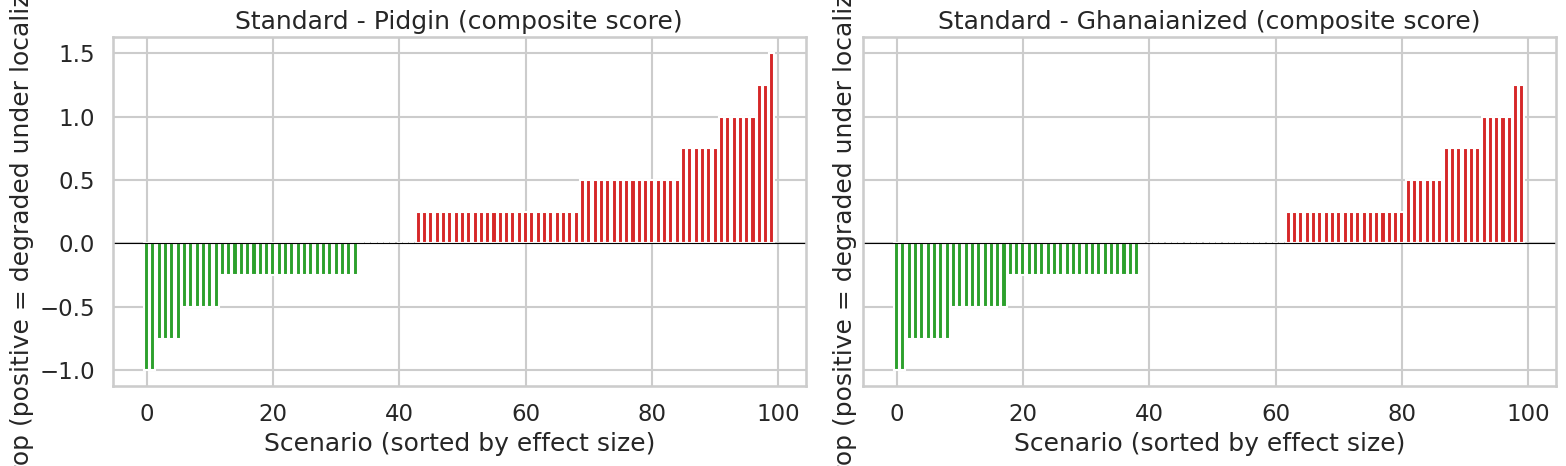

Scenarios where localized English performed WORSE than standard (composite):
  Pidgin:   57 / 100 scenarios
  Ghanaian: 38 / 100 scenarios


In [13]:
wide_composite = paired_wide('composite_score')
wide_composite['diff_pidgin']   = wide_composite['standard'] - wide_composite['pidgin']
wide_composite['diff_ghanaian'] = wide_composite['standard'] - wide_composite['ghanaian']

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, col, title, color in zip(
        axes,
        ['diff_pidgin', 'diff_ghanaian'],
        ['Standard - Pidgin (composite score)', 'Standard - Ghanaianized (composite score)'],
        ['#d62728', '#2ca02c']):
    sorted_vals = wide_composite[col].sort_values().reset_index(drop=True)
    colors = ['#d62728' if v > 0 else '#2ca02c' for v in sorted_vals]  # positive = degraded
    ax.bar(range(len(sorted_vals)), sorted_vals, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Scenario (sorted by effect size)')
    ax.set_ylabel('Score drop (positive = degraded under localized English)')

plt.tight_layout()
plt.savefig('fig5_per_scenario_degradation.png', dpi=150)
plt.show()

print("Scenarios where localized English performed WORSE than standard (composite):")
print(f"  Pidgin:   {(wide_composite['diff_pidgin'] > 0).sum()} / {len(wide_composite)} scenarios")
print(f"  Ghanaian: {(wide_composite['diff_ghanaian'] > 0).sum()} / {len(wide_composite)} scenarios")


In [14]:
summary = long_df.groupby('condition')[SCORE_COLS + ['composite_score']].mean().round(2)
summary = summary.loc[['standard', 'pidgin', 'ghanaian']]
summary['pct_change_vs_standard'] = ((summary['composite_score'] - summary.loc['standard', 'composite_score'])
                                      / summary.loc['standard', 'composite_score'] * 100).round(1)
summary


,professional_alignment,empathy_score,safety_score,relevance_score,composite_score,pct_change_vs_standard
condition,,,,,,
standard,3.95,2.80,5.0,4.03,3.94,0.0
pidgin,3.83,2.59,5.0,3.74,3.79,-3.8
ghanaian,3.96,2.77,5.0,3.94,3.92,-0.5


In [15]:
print("=== HYPOTHESIS CHECK ===")
print("H1: LLM response quality decreases for localized African English vs standard English.\n")

for compare in ['pidgin', 'ghanaian']:
    row = results_df[(results_df['metric'] == 'composite_score') & (results_df['comparison'] == f'standard vs {compare}')].iloc[0]
    direction = "DECREASED" if row['mean_diff'] > 0 else "INCREASED"
    sig = "statistically significant (p<0.05)" if row['significant_p<0.05'] else "NOT statistically significant"
    print(f"- standard vs {compare}: composite score {direction} by {abs(row['mean_diff'])} points "
          f"(Cohen's d = {row['cohens_d']}), {sig} (paired t p={row['paired_t_p']}, Wilcoxon p={row['wilcoxon_p']}).")


=== HYPOTHESIS CHECK ===
H1: LLM response quality decreases for localized African English vs standard English.

- standard vs pidgin: composite score DECREASED by 0.16 points (Cohen's d = 0.31), statistically significant (p<0.05) (paired t p=0.0027, Wilcoxon p=0.0034).
- standard vs ghanaian: composite score DECREASED by 0.03 points (Cohen's d = 0.06), NOT statistically significant (paired t p=0.5746, Wilcoxon p=0.7522).
